In [1]:
pip install pyroll-core pyroll-cli pyroll-export

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
print("Python version:", sys.version)
print("Python executable:", sys.executable)

Python version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
Python executable: C:\Users\keert\anaconda3\python.exe


In [3]:
import subprocess
import sys
subprocess.run([sys.executable, "-m", "pip", "install", 
                "pyroll-core", "pyroll-cli", "pyroll-export"], 
               capture_output=False)

CompletedProcess(args=['C:\\Users\\keert\\anaconda3\\python.exe', '-m', 'pip', 'install', 'pyroll-core', 'pyroll-cli', 'pyroll-export'], returncode=0)

In [4]:
import pyroll.core as pr
from importlib.metadata import version

print("PyRolL version:", version("pyroll-core"))
print("Import successful ✓")
print("PyRolL imported:", pr)

PyRolL version: 3.1.1
Import successful ✓
PyRolL imported: <module 'pyroll.core' from 'C:\\Users\\keert\\anaconda3\\Lib\\site-packages\\pyroll\\core\\__init__.py'>


In [5]:
import pyroll.core as pr

# Define a simple round-to-oval rolling pass
sequence = pr.PassSequence([
    pr.RollPass(
        label="Oval Pass",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=6e-3,    # inner radius 6mm
                r2=40e-3,   # outer radius 40mm
                depth=8e-3  # groove depth 8mm
            ),
            nominal_radius=160e-3,   # roll radius 160mm
            rotational_frequency=1,  # 1 rotation/second
        ),
        gap=2e-3,  # roll gap 2mm
    )
])

# Define the incoming material (round bar)
incoming = pr.RoundProfile(
    radius=30e-3,   # 30mm radius incoming bar
    temperature=1200 + 273.15,  # 1200°C in Kelvin
    strain=0,
    length=1,
    material="S355",  # structural steel
)

print("Setup complete ✓")
print(f"Incoming bar radius: {incoming.radius*1000:.1f} mm")
print(f"Incoming temperature: {incoming.temperature - 273.15:.0f} °C")
print(f"Roll radius: {sequence[0].roll.nominal_radius*1000:.0f} mm")
print(f"Roll gap: {sequence[0].gap*1000:.1f} mm")

Setup complete ✓
Incoming bar radius: 30.0 mm
Incoming temperature: 1200 °C
Roll radius: 160 mm
Roll gap: 2.0 mm


In [6]:
diameter = 60  # mm
reduction_per_pass = 0.20  # 20% each pass
target = 20  # mm

pass_num = 0
while diameter > target:
    diameter = diameter * (1 - reduction_per_pass)
    pass_num += 1
    print(f"Pass {pass_num}: {diameter:.1f} mm")

print(f"\nTotal passes needed: {pass_num}")

Pass 1: 48.0 mm
Pass 2: 38.4 mm
Pass 3: 30.7 mm
Pass 4: 24.6 mm
Pass 5: 19.7 mm

Total passes needed: 5


In [7]:
diameter = 48
reduction_per_pass = 0.20
target = 20

pass_num = 0
while diameter > target:
    diameter = diameter * (1 - reduction_per_pass)
    pass_num += 1
    print(f"Pass {pass_num} : {diameter: .1f} mm")

print(f"\nTotal passes needed: {pass_num}")


Pass 1 :  38.4 mm
Pass 2 :  30.7 mm
Pass 3 :  24.6 mm
Pass 4 :  19.7 mm

Total passes needed: 4


In [8]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", 
                "pyroll-wusatowski-spreading"])

CompletedProcess(args=['C:\\Users\\keert\\anaconda3\\python.exe', '-m', 'pip', 'install', 'pyroll-wusatowski-spreading'], returncode=0)

In [9]:
import pyroll.wusatowski_spreading
print(dir(pyroll.wusatowski_spreading))

['Hook', 'PILLAR_MODEL_LOADED', 'RollPass', 'SymmetricRollPass', 'ThreeRollPass', 'VERSION', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'logging', 'width', 'wusatowski_exponent_high_strain', 'wusatowski_exponent_low_strain', 'wusatowski_friction_coefficient', 'wusatowski_material_coefficient', 'wusatowski_temperature_coefficient', 'wusatowski_velocity_coefficient']


In [10]:
from importlib.metadata import version
print(version("pyroll-wusatowski-spreading"))

3.0.0


In [11]:
import pyroll.core as pr
import pyroll.wusatowski_spreading # We started with a 60mm diameter round bar. After Pass 1 the width is 65mm — it actually got wider.
                                    #  Spreading behaviour is a separate physics model that lives in its own plugin — because there are many different spreading models (Wusatowski, Freiberg, Neutral point etc.) and you choose which one to use.
                                    # Without importing a spreading plugin, PyRolL has no equation to calculate how much the material spreads sideways — so it makes a simplified assumption, which is why your results are off.
                                    # This is actually directly relevant to your thesis topic — foil rolling has very different spreading behaviour than groove rolling because of elastic roll deformation. The Le & Sutcliffe model you'll implement handles this differently.


in_profile = pr.Profile.round(
    radius=30e-3,        # 60mm diameter incoming
    temperature=1200 + 273.15,
    strain=0,
    material=["steel", "C15"],
    flow_stress=100e6,
    density=7.5e3,
    specific_heat_capacity=690,
)

sequence = pr.PassSequence([
    pr.RollPass(
        label="Pass 1",
        roll=pr.Roll(
            groove=pr.CircularOvalGroove(
                r1=2e-3,
                r2=50e-3,
                depth=12e-3
            ),
            nominal_radius=160e-3,
             rotational_frequency=1, # PyRolL needs to know the roll speed to calculate everything else
                                        # Without rotational_frequency it can't calculate velocity → everything downstream fails.
        ),
        gap=42e-3/2,  # ~30% reduction from 60mm / 2
    ),
    # YOUR TURN: Add Pass 2, 3, 4, 5
    # Each pass reduces diameter by ~20%
    # Adjust groove depth and gap accordingly
    
    pr.RollPass(
    label="Pass 2",
    roll=pr.Roll(
        groove=pr.CircularOvalGroove(
            r1=2e-3,
            r2=40e-3,
            depth=10e-3
        ),
        nominal_radius=160e-3,
         rotational_frequency=1,
    ),
    gap=29.4e-3/2,  # 38.4mm exit diameter / 2
),
    pr.RollPass(
    label="Pass 3",
    roll=pr.Roll(
        groove=pr.CircularOvalGroove(
            r1=2e-3,
            r2=40e-3,
            depth=10e-3
        ),
        nominal_radius=160e-3,
         rotational_frequency=1,
    ),
    gap=20.6e-3/2,  # 30.7mm exit diameter / 2
),
    pr.RollPass(
    label="Pass 4",
    roll=pr.Roll(
        groove=pr.CircularOvalGroove(
            r1=2e-3,
            r2=30.7e-3,
            depth=10e-3
        ),
        nominal_radius=160e-3,
         rotational_frequency=1,
    ),
    gap=14.4e-3/2,  # 24.6mm exit diameter / 2
),
])

sequence.solve(in_profile)

# Print exit profile of each pass
for pass_ in sequence:
    if isinstance(pass_, pr.RollPass):
        print(f"{pass_.label}: "
              f"exit width = {pass_.out_profile.width*1000:.1f} mm, "
              f"exit height = {pass_.out_profile.height*1000:.1f} mm")

Pass 1: exit width = 65.0 mm, exit height = 45.0 mm
Pass 2: exit width = 61.7 mm, exit height = 34.7 mm
Pass 3: exit width = 50.9 mm, exit height = 30.3 mm
Pass 4: exit width = 43.7 mm, exit height = 27.2 mm


In [12]:
diameter = 60  # mm
reduction_per_pass = 0.30  # increase to 30%
target = 20  # mm

pass_num = 0
while diameter > target:
    diameter = diameter * (1 - reduction_per_pass)
    pass_num += 1
    print(f"Pass {pass_num}: {diameter:.1f} mm")

print(f"\nTotal passes needed: {pass_num}")

Pass 1: 42.0 mm
Pass 2: 29.4 mm
Pass 3: 20.6 mm
Pass 4: 14.4 mm

Total passes needed: 4


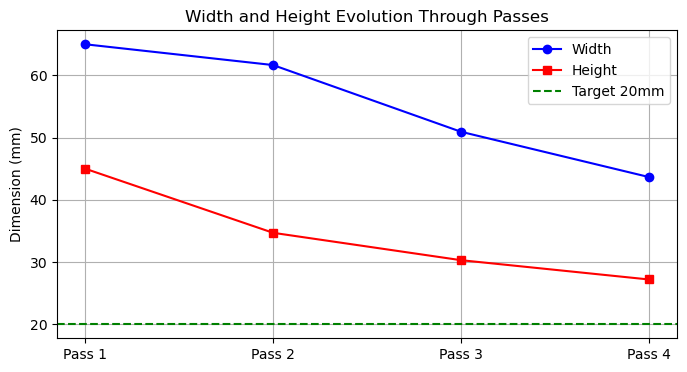

In [13]:
"""We wanted ~14mm. Still quite far off.
You already understand why — spreading is stealing elongation.
Here's the real insight for your thesis: This is exactly the problem with foil rolling. At very thin gauges, elastic roll deformation makes this even worse — the rolls themselves bend away from the material, so the actual gap is larger than what you set.
That's precisely what the Le & Sutcliffe model solves."""

import matplotlib.pyplot as plt

passes = [f"Pass {i+1}" for i in range(4)]
widths = [pass_.out_profile.width*1000 
          for pass_ in sequence 
          if isinstance(pass_, pr.RollPass)]
heights = [pass_.out_profile.height*1000 
           for pass_ in sequence 
           if isinstance(pass_, pr.RollPass)]

plt.figure(figsize=(8,4))
plt.plot(passes, widths, 'bo-', label='Width')
plt.plot(passes, heights, 'rs-', label='Height')
plt.axhline(y=20, color='green', linestyle='--', label='Target 20mm')
plt.ylabel('Dimension (mm)')
plt.title('Width and Height Evolution Through Passes')
plt.legend()
plt.grid(True)
plt.show()


""" Your first real engineering plot! 🎯
Look at what this graph is telling you — this is genuinely useful information.
Two observations I want you to make:

The blue line (width) is barely decreasing — it goes from 65mm to 43mm across 4 passes. The red line (height) drops much faster. What does this tell you about where the material is going?
Both lines are still far above the green target line.

Here's the bigger picture insight — look at the gap between width and height. In rolling, ideally you want a round exit profile where width ≈ height. But your width is consistently ~15-20mm larger than height every pass.
This is why real rolling mills use alternating oval-round pass sequences — you squeeze in one direction, then rotate 90° and squeeze the other way. That's how you control spread and reach your target dimensions efficiently.
This is real rolling mill engineering you just discovered yourself through simulation.  """